# Exploratory Data Analysis (EDA) - Sample Superstore Dataset
---

### Project Overview
The objective of this project is to perform comprehensive Exploratory Data Analysis on the **Sample Superstore Dataset** to identify sales trends, evaluate profit margins across categories, analyze discount impacts, and derive actionable business recommendations.

In [1]:
# 1. Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11


## 1. Data Loading & Initial Inspection
Loading the dataset and examining its basic structure, shape, columns, and initial summary statistics.

In [2]:
# Load dataset
df = pd.read_csv('SampleSuperstoreDataset.csv')

# Display shape and first 5 rows
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head()

Dataset Shape: 9994 rows, 13 columns



,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
# Dataset schema and types
print("=" * 50)
print(" \t \tData Information ")
print("=" * 50)
df.info()

print()
# Summary statistics for numerical features
print("=" * 80)
print("\t\t Numerical Summary Statistics ")
print("=" * 80)
df.describe().T

 	 	Data Information 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB

		 Numerical Summary Statistics 


,count,mean,std,min,25%,50%,75%,max
Postal Code,9994.0,55190.379428,32063.693350,1040.000,23223.00000,56430.5000,90008.000,99301.000
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


## 2. Data Cleaning & Preprocessing
In this step, we check for:
- Missing/Null values
- Duplicate records
- Dropping redundant/constant columns (`Country` has only 1 unique value, `Postal Code` is not needed for aggregate business analysis)

In [5]:
# Check for missing values
print("=" * 50)
print("\tMissing values per column")
print("=" * 50)
print(df.isnull().sum())

# Check and remove duplicates
duplicates_count = df.duplicated().sum()
print(f"\nDuplicate rows found: {duplicates_count}")

if duplicates_count > 0:
    df = df.drop_duplicates()
    print(f"Duplicates dropped. Cleaned dataset shape: {df.shape}")

# Drop redundant columns
df = df.drop(columns=['Country', 'Postal Code'], errors='ignore')
print(f"Remaining columns: {list(df.columns)}")

	Missing values per column
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Duplicate rows found: 17
Duplicates dropped. Cleaned dataset shape: (9977, 13)
Remaining columns: ['Ship Mode', 'Segment', 'City', 'State', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']


In [6]:
# Save the cleaned dataset to a CSV file
cleaned_file_path = 'Cleaned_SampleSuperstoreDataset.csv'
df.to_csv(cleaned_file_path, index=False)

print(f"Cleaned dataset successfully saved as '{cleaned_file_path}'")
print(f"Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")

Cleaned dataset successfully saved as 'Cleaned_SampleSuperstoreDataset.csv'
Total rows: 9977, Total columns: 11


## 3. Exploratory Data Analysis & Visualizations

We will generate the 5 required visualizations:
1. **Histogram:** Distribution of Sales and Profit
2. **Bar Chart:** Total Sales & Profit across Sub-Categories
3. **Scatter Plot:** Relationship between Sales and Profit (Segmented by Discount)
4. **Correlation Heatmap:** Correlation between numerical attributes
5. **Line Chart:** Impact of Discount Rates on Average Profit Margin

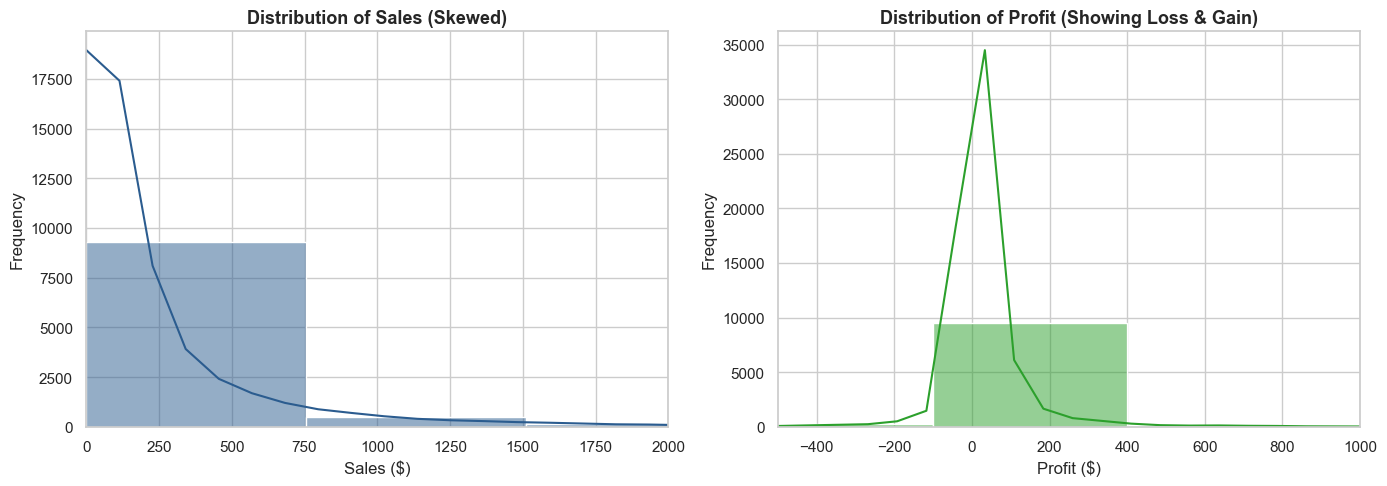

In [7]:
# Visualization 1: Distribution of Sales & Profit (Histograms)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales distribution (Log scale for clarity due to skewness)
sns.histplot(df['Sales'], kde=True, ax=axes[0], color='#2b5c8f', bins=30)
axes[0].set_title('Distribution of Sales (Skewed)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 2000)

# Profit distribution
sns.histplot(df['Profit'], kde=True, ax=axes[1], color='#2ca02c', bins=30)
axes[1].set_title('Distribution of Profit (Showing Loss & Gain)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Profit ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(-500, 1000)

plt.tight_layout()
plt.savefig('01_sales_profit_distribution.png', dpi=300)
plt.show()

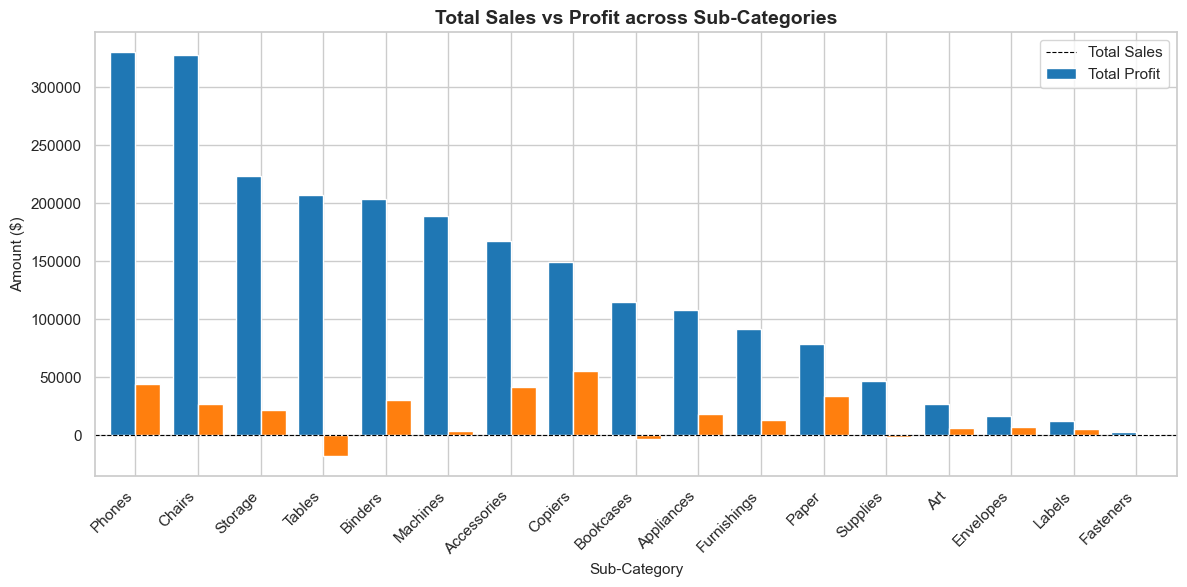

In [8]:
# Visualization 2: Sales & Profit by Sub-Category
subcat_perf = df.groupby('Sub-Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
subcat_perf.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'], width=0.8)

plt.title('Total Sales vs Profit across Sub-Categories', fontsize=14, fontweight='bold')
plt.xlabel('Sub-Category', fontsize=11)
plt.ylabel('Amount ($)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.legend(['Total Sales', 'Total Profit'])
plt.tight_layout()
plt.savefig('02_subcategory_sales_profit.png', dpi=300)
plt.show()

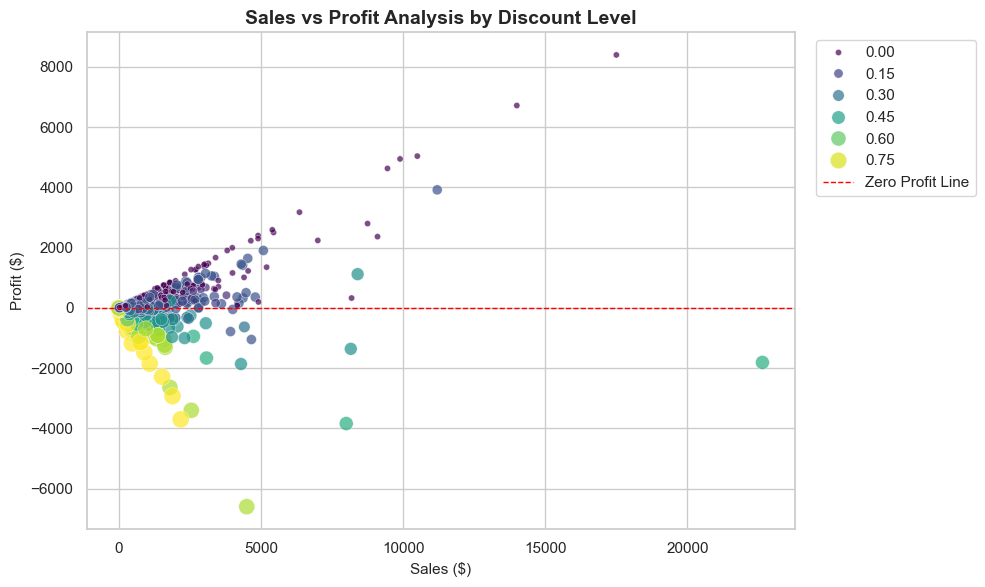

In [9]:
# Visualization 3: Scatter Plot of Sales vs Profit
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Sales', 
    y='Profit', 
    hue='Discount', 
    palette='viridis', 
    size='Discount', 
    sizes=(20, 150),
    alpha=0.7
)

plt.title('Sales vs Profit Analysis by Discount Level', fontsize=14, fontweight='bold')
plt.xlabel('Sales ($)', fontsize=11)
plt.ylabel('Profit ($)', fontsize=11)
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Zero Profit Line')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('03_scatter_sales_profit_discount.png', dpi=300)
plt.show()

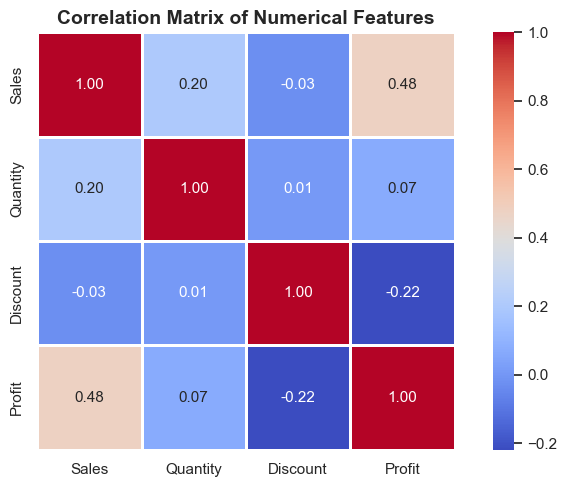

In [10]:
# Visualization 4: Correlation Heatmap
plt.figure(figsize=(8, 5))
corr_matrix = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1, square=True)
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=300)
plt.show()

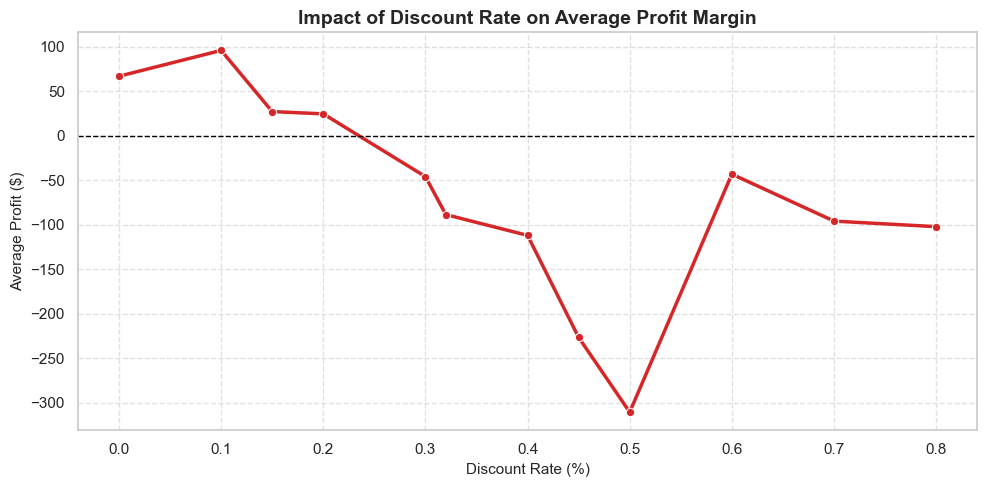

In [11]:
# Visualization 5: Line Plot - Average Profit vs Discount Rate
discount_profit = df.groupby('Discount')['Profit'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=discount_profit, x='Discount', y='Profit', marker='o', color='#d62728', linewidth=2.5)

plt.title('Impact of Discount Rate on Average Profit Margin', fontsize=14, fontweight='bold')
plt.xlabel('Discount Rate (%)', fontsize=11)
plt.ylabel('Average Profit ($)', fontsize=11)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('05_discount_vs_profit_trend.png', dpi=300)
plt.show()

## 4. Key Insights & Business Recommendations

### **Key Findings:**
1. **Discounting Causes Major Losses:** A strong negative relationship exists between high discounts and profitability. Giving discounts above **20%** consistently leads to negative profit margins.
2. **Loss-Making Categories:** Sub-categories such as **Tables**, **Bookcases**, and **Supplies** suffer net losses despite generating substantial sales volume.
3. **High-Performing Segments:** **Technology** (specifically *Copiers* and *Phones*) and the **West Region** yield the highest profit margins with manageable discount sensitivities.

---

### **Actionable Recommendations:**
* **Discount Capping:** Cap promotional discounts at **15%–20%**. Any discount above 20% should require special managerial approval.
* **Restructure Pricing for Tables & Bookcases:** Re-evaluate supplier contracts, increase base prices, or bundle these loss-making items with high-margin accessories.
* **Target High-Margin Regions:** Prioritize marketing spend in the West and East regions where customer segments show higher willingness to buy at full price.